In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# %cd /content/drive/MyDrive/Dataset/25886_Kritika_Gupta_Assignment_2

In [3]:
import torch
import numpy as np
from tqdm import tqdm
from scipy.stats import wilcoxon
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, random_split
from segmentation.model import SegmentationModel, compute_iou_batch,SegmentationDataset, preprocess_seg


# Wilcoxson Test

In [4]:
def get_per_image_miou(model, dataloader):
    model.model.eval()
    miou_list = []

    with torch.no_grad():
        for images, masks in tqdm(dataloader):
            images = images.to(model.device)
            masks = masks.to(model.device)

            outputs = model.model(images)
            preds = torch.argmax(outputs, dim=1)

            # compute per-image IoU
            for p, m in zip(preds, masks):
                iou = compute_iou_batch(p.unsqueeze(0), m.unsqueeze(0))
                miou_list.append(iou)

    return miou_list

In [5]:
FOLDER_PATH = "../"
training_path =   FOLDER_PATH + "train/"

dataset = SegmentationDataset(training_path, transform=preprocess_seg)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False,num_workers=2)

In [6]:
seg_model_A = SegmentationModel(weights_dir="segmentation/weights",model_weights='model_seg_no_skip_10epoch_5e-4lr.pth',use_skipconnections=False)
seg_model_B = SegmentationModel(weights_dir="segmentation/weights",model_weights='model_seg_skip_10epochs_1e-4lr.pth',use_skipconnections=True)


c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded trained segmentation weights
Loaded trained segmentation weights


In [7]:
miou_A = get_per_image_miou(seg_model_A, val_loader)
miou_B = get_per_image_miou(seg_model_B, val_loader)

stat, p_value = wilcoxon(miou_A, miou_B)

print("Wilcoxon Test Statistic:", stat)
print("p-value:", p_value)

100%|██████████| 28/28 [00:56<00:00,  2.01s/it]

Wilcoxon Test Statistic: 31497.0
p-value: 2.5714001305295577e-06


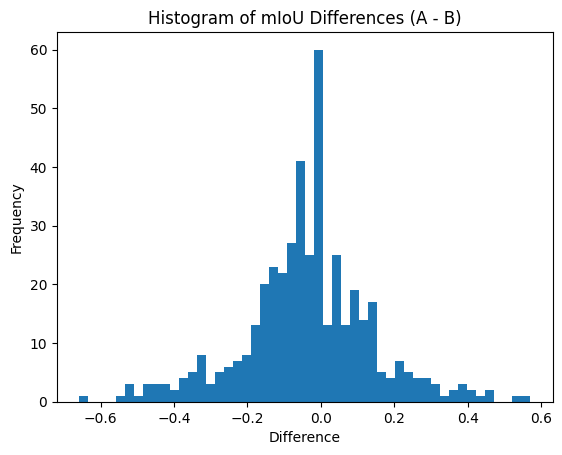

In [8]:
diff = np.array(miou_A) - np.array(miou_B)

plt.hist(diff, bins=50)
plt.title("Histogram of mIoU Differences (A - B)")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

# Bootstrap

In [9]:
def bootstrap_miou(miou_list, B=1000):
    miou_array = np.array(miou_list)
    n = len(miou_array)

    bootstrap_means = []

    for _ in range(B):
        sample = np.random.choice(miou_array, size=n//2, replace=True)
        bootstrap_means.append(np.mean(sample))

    return np.array(bootstrap_means)

In [10]:
overall_miou = np.mean(miou_B)

bootstrap_samples = bootstrap_miou(miou_B, B=1000)
mean = np.mean(bootstrap_samples)
std_error = np.std(bootstrap_samples)

ci_lower = np.percentile(bootstrap_samples, 2.5)
ci_upper = np.percentile(bootstrap_samples, 97.5)

print("Overall mIoU:", overall_miou)
print("Bootstrap Mean:", mean)
print("Standard Error:", std_error)
print("95% CI:", (ci_lower, ci_upper))

Overall mIoU: 0.4630364421816027
Bootstrap Mean: 0.46253652877528745
Standard Error: 0.016480667501120497
95% CI: (np.float64(0.43142556794095394), np.float64(0.4941288259344661))
